Quantum State Tomography

In [7]:
# QST measurement simulation function
from ast import operator
import itertools as it
import numpy as np
from qutip import *
import pandas as pd
from scipy.linalg import hadamard
from scipy.optimize import minimize

class QSTSim:

    def __init__(self, nqubits, shots, rho):
        self.nqubits = nqubits
        self.shots = shots
        self.hadamard = hadamard(2**self.nqubits) # import from scipy which is
        #not normalized. Not H gate
        self.rho = rho
        self.expectationval_list = []

    def calc_theoritical_probs(self):
        settings = list(it.product(["X", "Y", "Z"], repeat=self.nqubits))
        # returns all combnations for e.g. in 2 qubit case XX, XY, YZ so on
        
        # Z basis projectors
        Pz_plus = ket2dm(basis(2,0))  
        Pz_minus = ket2dm(basis(2,1))

        xplus = (basis(2,0) + basis(2,1)).unit()
        xminus = (basis(2,0) - basis(2,1)).unit()

        # X basis projectors
        Px_plus = ket2dm(xplus) # ket to density matrix
        Px_minus = ket2dm(xminus)

        # Y basis projectors
        p_i = (basis(2,0) + 1j*basis(2,1)).unit()
        m_i = (basis(2,0) - 1j*basis(2,1)).unit()

        Py_plus = ket2dm(p_i)
        Py_minus = ket2dm(m_i)

        proj_lookup = {"X": [Px_plus, Px_minus],
                "Y": [Py_plus, Py_minus],
                "Z": [Pz_plus, Pz_minus]}

        outcomes = list(it.product([0,1], repeat=self.nqubits)) # one time gen of e.g. [00, 01, 10, 11]
        #for 2 qubits. This represents +1, -1 measurements

        prob_dict = {}
        tens_mat = {}
        for setting in settings:
            projectors = []
            for outcome in outcomes:
                operators = []
                for qubit, b in enumerate(setting):
                    operators.append(proj_lookup[b][outcome[qubit]])
                projectors.append(tensor(*operators))                

            # compute probabilities
            probs = []

            for P in projectors:
                prob = np.real((P * self.rho).tr()) # tr(P*rho) = prob coress to P
                probs.append(prob)

            # ---- store results ----
            prob_dict[setting] = probs
            tens_mat[setting] = projectors   
        return prob_dict, tens_mat 

   
    def measure_qubits(self):
        theoritical_prob_dict, tensor_mat = self.calc_theoritical_probs()
        possible_outcomes = list(it.product([-1,1], repeat=self.nqubits))
        idx = np.arange(len(possible_outcomes))
       
        measured_outcome_count_list = []
        measured_probs_list = []
        self.shots_per_basis = int(self.shots/(3**self.nqubits)) # shots per basis setting, e.g. if 2 qubit ie 1000/3^2 = 1000/9 = 111 shots per basis setting
        for i, theory_prob in enumerate(theoritical_prob_dict.values()): # i is index of basis setting, prob is list of probabilities for that setting e.g [0.25, .25, .25, .25] for 2 qubits
            measure_outcome_index = list(np.random.choice(len(possible_outcomes), self.shots_per_basis, p=theory_prob)) # choice takes in the probabilities for that basis setting and generates a list of measurement outcomes (e.g. 1000 samples of 0,1,2,3 for 2 qubits) based on those probabilities
            measured_outcome_counts = np.array([measure_outcome_index.count(x) for x in idx]) # counts the number of times each outcome (0,1,2,3) occurs in the measure list and divides by total shots to get probabilities for each outcome based on the simulated measurements
            measured_outcome_count_list.append(measured_outcome_counts)
            measured_probs = measured_outcome_counts/self.shots_per_basis
            measured_probs_list.append(measured_probs)
            expectationvals = np.dot(self.hadamard, measured_probs) # frequency * hadamard to get expectation values for that basis setting
            self.expectationval_list.append(expectationvals)

        return self.expectationval_list, measured_outcome_count_list, measured_probs_list   


    def print_probs(self, prob_dict):
        rows = []
        for setting, probs in prob_dict.items():
            rows.append({
                "Basis": "".join(setting),
                "(+1,+1)": probs[0],
                "(+1,-1)": probs[1],
                "(-1,+1)": probs[2],
                "(-1,-1)": probs[3]
            })

        df = pd.DataFrame(rows)
        print("Measurement for the Rho state:", self.rho)
        print("Printing probabilities:\n",df.to_string(index=False, float_format="%.2f"))

    def print_counts(self, count_list):

        labels = ["(+1,+1)", "(+1,-1)", "(-1,+1)", "(-1,-1)"]

        rows = []
        for i, counts in enumerate(count_list):
            rows.append({
                "Basis #": i,
                "(+1,+1)": counts[0],
                "(+1,-1)": counts[1],
                "(-1,+1)": counts[2],
                "(-1,-1)": counts[3]
            })

        df = pd.DataFrame(rows)
        print("\nMeasured probabilities (counts):")
        print(df.to_string(index=False, float_format="%.3f"))


    def print_expectations(self, expect_list):

        settings = list(it.product(["X","Y","Z"], repeat=self.nqubits))
        rows = []
        for i,(setting,e) in enumerate(zip(settings, expect_list)):
            labels = []
            for comb in it.product(["I","M"], repeat=self.nqubits): # M is just placeholder to replace the right operator among X, Y, Z
                label = ""
                for j,c in enumerate(comb):
                    label += "I" if c=="I" else setting[j]
                labels.append(label)

            row = {"Basis": "".join(setting)}

            for j,l in enumerate(labels):
                row[l] = e[j]

            rows.append(row)

        df = pd.DataFrame(rows)
        print("\nExpectation values:")
        print(df.to_string(index=False, float_format="%.3f"))  

    def linear_inversion_reconstruction(self):
        # reconstruct rho using linear inversion which is rho = sigma (epect_val*Pauli operator)
        # step 1: generate pauli basis for n qubits which is 4^n. For 2 qubits, it is (16) II, IX, 
        # IY, IZ, XI, XX, XY, XZ, YI, YX, YY, YZ, ZI, ZX, ZY, ZZ
        labels = list(it.product(["I","X","Y","Z"], repeat=self.nqubits))

        # step 2: generate measurement bases without I operator which is 3^n. For 2 qubits, it is 
        # XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ
        measure_ops = list(it.product(["X","Y","Z"], repeat=self.nqubits))

        # step 3: we need to extract the expectn values from expect_list
        # we need it for each of the 16 measure ops
        # so for each of the measure ops we will create its 4 (2^n) ops say it is XX then II, 
        # IX, XI, XX. Then we will find for each of the ops what is the coress expect values
        # rmbr expect is list is of the form (9,4) for 2 qubits

        expect_dict = {}

        for measure_op, e in zip(measure_ops, self.expectationval_list):
            possible_ops_labels = []
            for ops_pair in list(it.product(["I", "M"], repeat=self.nqubits)):
                op_label=""
                for index, op in enumerate(ops_pair):
                    op_label +="I" if op=="I" else measure_op[index]
                possible_ops_labels.append(op_label)

            for op, eval in zip(possible_ops_labels, e):
                if op not in expect_dict:
                    expect_dict[op] = []
                expect_dict[op].append(eval)
            
        for k in expect_dict:
            expect_dict[k] = np.mean(expect_dict[k])

        expect_dict["I"*self.nqubits] = 1

        # step 4: build pauli operators
        pauli = {
            "I": qeye(2),
            "X": sigmax(),
            "Y": sigmay(),
            "Z": sigmaz()
        }

        # step 5: reconstruct rho
        rho_rec = 0

        for label in labels:
            label_str = "".join(label)
            pauli_operator = tensor(*[pauli[p] for p in label])
            rho_rec += expect_dict[label_str] * pauli_operator

        rho_rec = rho_rec / (2**self.nqubits)
        print("\nReconstructed rho:\n", rho_rec)
        print("Reconstructed rho is Hermitian:", rho_rec.isherm)
        print("Reconstructed Rho Trace:", rho_rec.tr())
        print("Reconstructed rho Eigenvalues:", rho_rec.eigenenergies())
        print("Fidelity:", fidelity(self.rho, rho_rec))
        return rho_rec


    def max_likelihood_estimation(self):
        dims = [[2] * self.nqubits, [2] * self.nqubits]  # define once here
        prob_dict, tensor_matrices = self.calc_theoritical_probs()
        _, measured_count_list, _ = self.measure_qubits()

        #right now count is per basis setting e.g. XX, XY XZ so on. Similarly projectors are akso keyed per setting so lets flatten
        projectors = []
        E_i_list = []
        n_i_list = []
        for setting_idx, setting in enumerate(tensor_matrices.keys()):
            projectors = tensor_matrices[setting]
            counts = measured_count_list[setting_idx]
            for i in range(len(projectors)):
                E_i_list.append(projectors[i])
                n_i_list.append(counts[i])  

        def build_T(t):
            dim = 2 ** self.nqubits # matrix dim
            T = np.zeros((dim, dim), dtype=complex) # init to be complex matrix of dim 2^n x 2^n
            idx = 0
            for i in range(dim):

                # diagonal (real)
                T[i, i] = t[idx] # fill diagonal with real numbers
                idx += 1

                for j in range(i):
                    T[i, j] = t[idx] + 1j * t[idx + 1]
                    idx += 2

            return T

        def build_rho(t):
            T = build_T(t)
            rho = T @ T.conj().T
            return rho / np.trace(rho)

        def loss(t):
            rho = build_rho(t)
            total = 0

            for E, n in zip(E_i_list, n_i_list):
                # inside loss():
                # compute p_i = Tr(ρ E_i)
                p = np.real((E * Qobj(rho, dims=dims)).tr())

                # avoid log(0)
                p = max(p, 1e-10)

                total -= n * np.log(p)

            return total
        
        dim = 2 ** self.nqubits
        num_params = dim + 2 * (dim * (dim - 1) // 2)
        t_init = np.random.randn(num_params)
        result = minimize(loss, t_init, method='L-BFGS-B')
        rho_final = build_rho(result.x)
        # at the end:
        rho_qobj = Qobj(rho_final, dims=dims)

        print("\nMLE Reconstructed rho:\n", rho_qobj)
        print("Hermitian:", rho_qobj.isherm)
        print("Trace:", rho_qobj.tr())
        print("Eigenvalues:", rho_qobj.eigenenergies())
        print("Fidelity:", fidelity(self.rho, rho_qobj))

        return rho_qobj


def test_calc_probs(sim: QSTSim):
    prob_dict, tensor_mat = sim.calc_theoritical_probs()
    sim.print_probs(prob_dict)


def test_measure(sim: QSTSim):
    expectation_list, count_list, prob_list = sim.measure_qubits()
    sim.print_counts(prob_list)
    sim.print_expectations(expectation_list) # expectations = Hadamard × probabilities
    print("Dim of counts", np.array(prob_list).shape)
    print("Dim of expect_list", np.array(expectation_list).shape)

def test_linear_inversion_reconstruction(sim: QSTSim):
    sim.linear_inversion_reconstruction()


def test_MLE(sim: QSTSim):
    sim.max_likelihood_estimation()

sim = QSTSim(2, 1000, tensor(basis(2,0), basis(2,0)) * tensor(basis(2,0), basis(2,0)).dag()) #|00><00|
test_calc_probs(sim)
test_measure(sim)
test_linear_inversion_reconstruction(sim)
test_MLE(sim)



Measurement for the Rho state: Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Printing probabilities:
 Basis  (+1,+1)  (+1,-1)  (-1,+1)  (-1,-1)
   XX     0.25     0.25     0.25     0.25
   XY     0.25     0.25     0.25     0.25
   XZ     0.50     0.00     0.50     0.00
   YX     0.25     0.25     0.25     0.25
   YY     0.25     0.25     0.25     0.25
   YZ     0.50     0.00     0.50     0.00
   ZX     0.50     0.50     0.00     0.00
   ZY     0.50     0.50     0.00     0.00
   ZZ     1.00     0.00     0.00     0.00

Measured probabilities (counts):
 Basis #  (+1,+1)  (+1,-1)  (-1,+1)  (-1,-1)
       0    0.207    0.306    0.234    0.252
       1    0.279    0.225    0.252    0.243
       2    0.450    0.000    0.550    0.000
       3    0.261    0.198    0.351    0.189
       4    0.234    0.243    0.270    0.252
       5    0.523    0.000    0.477    0.000
       6    0.523 

Code structure for easy reading

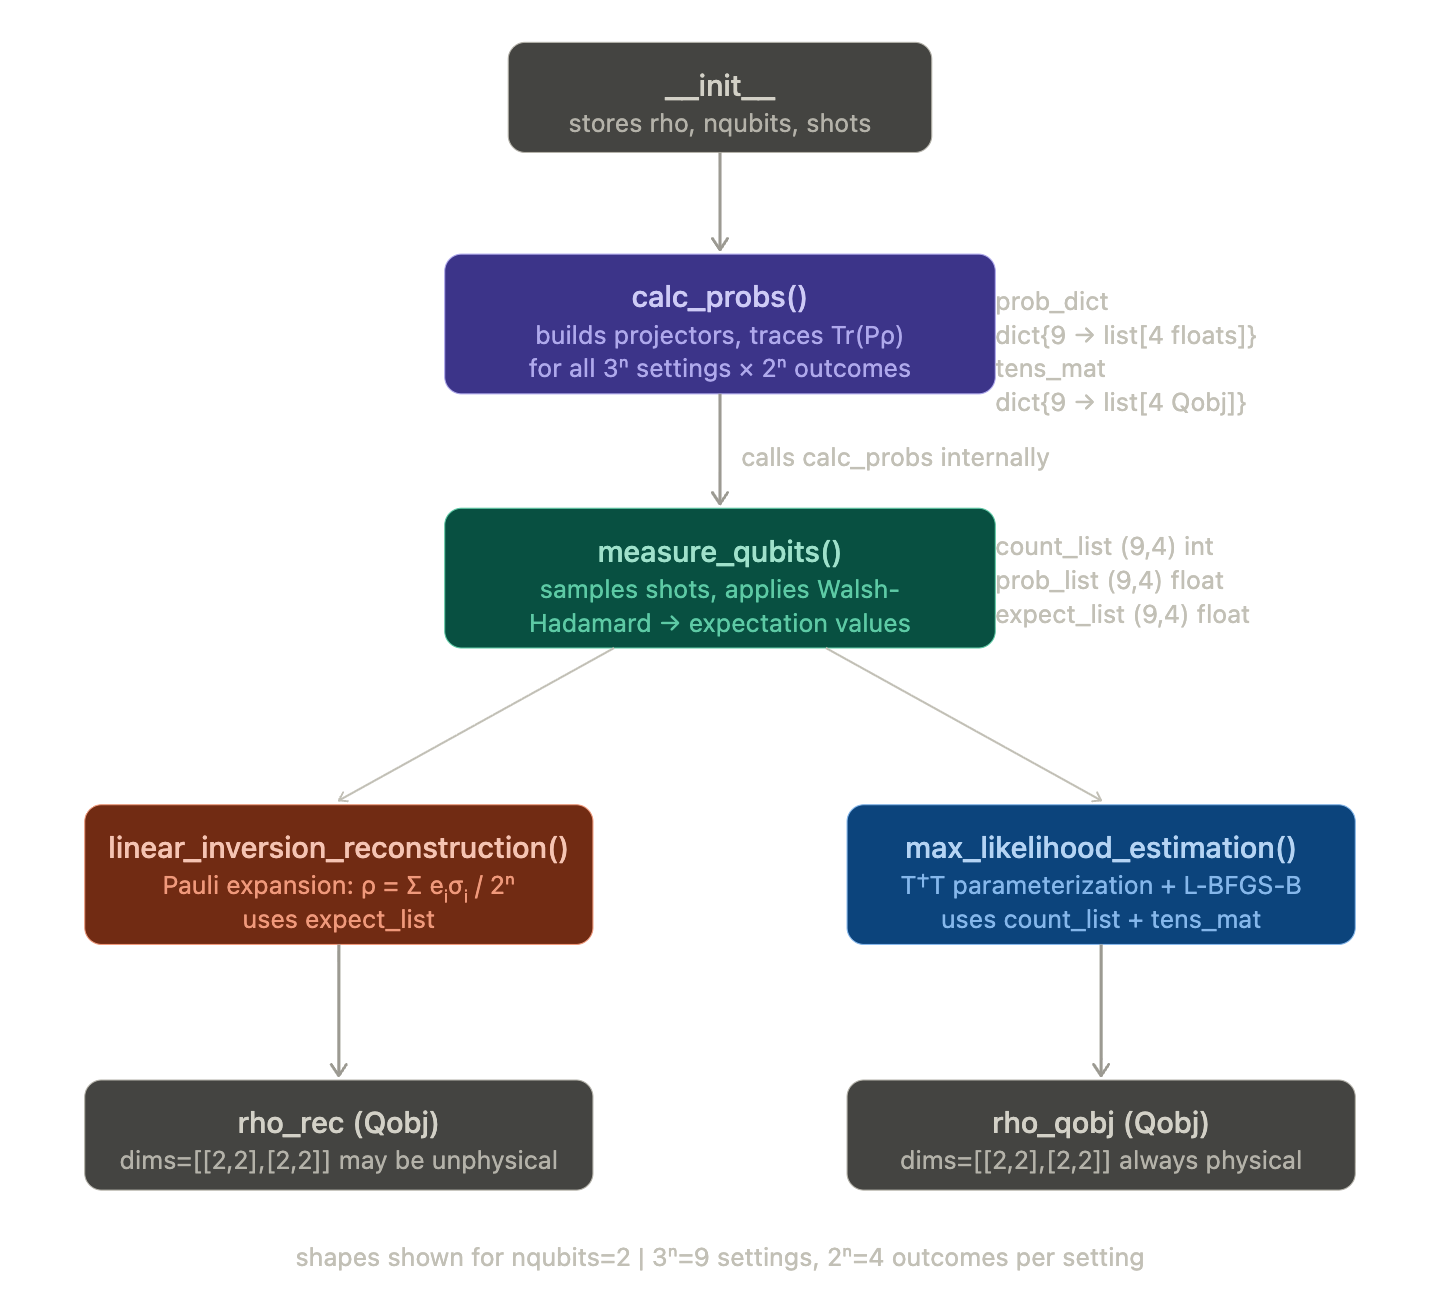

MLE internals

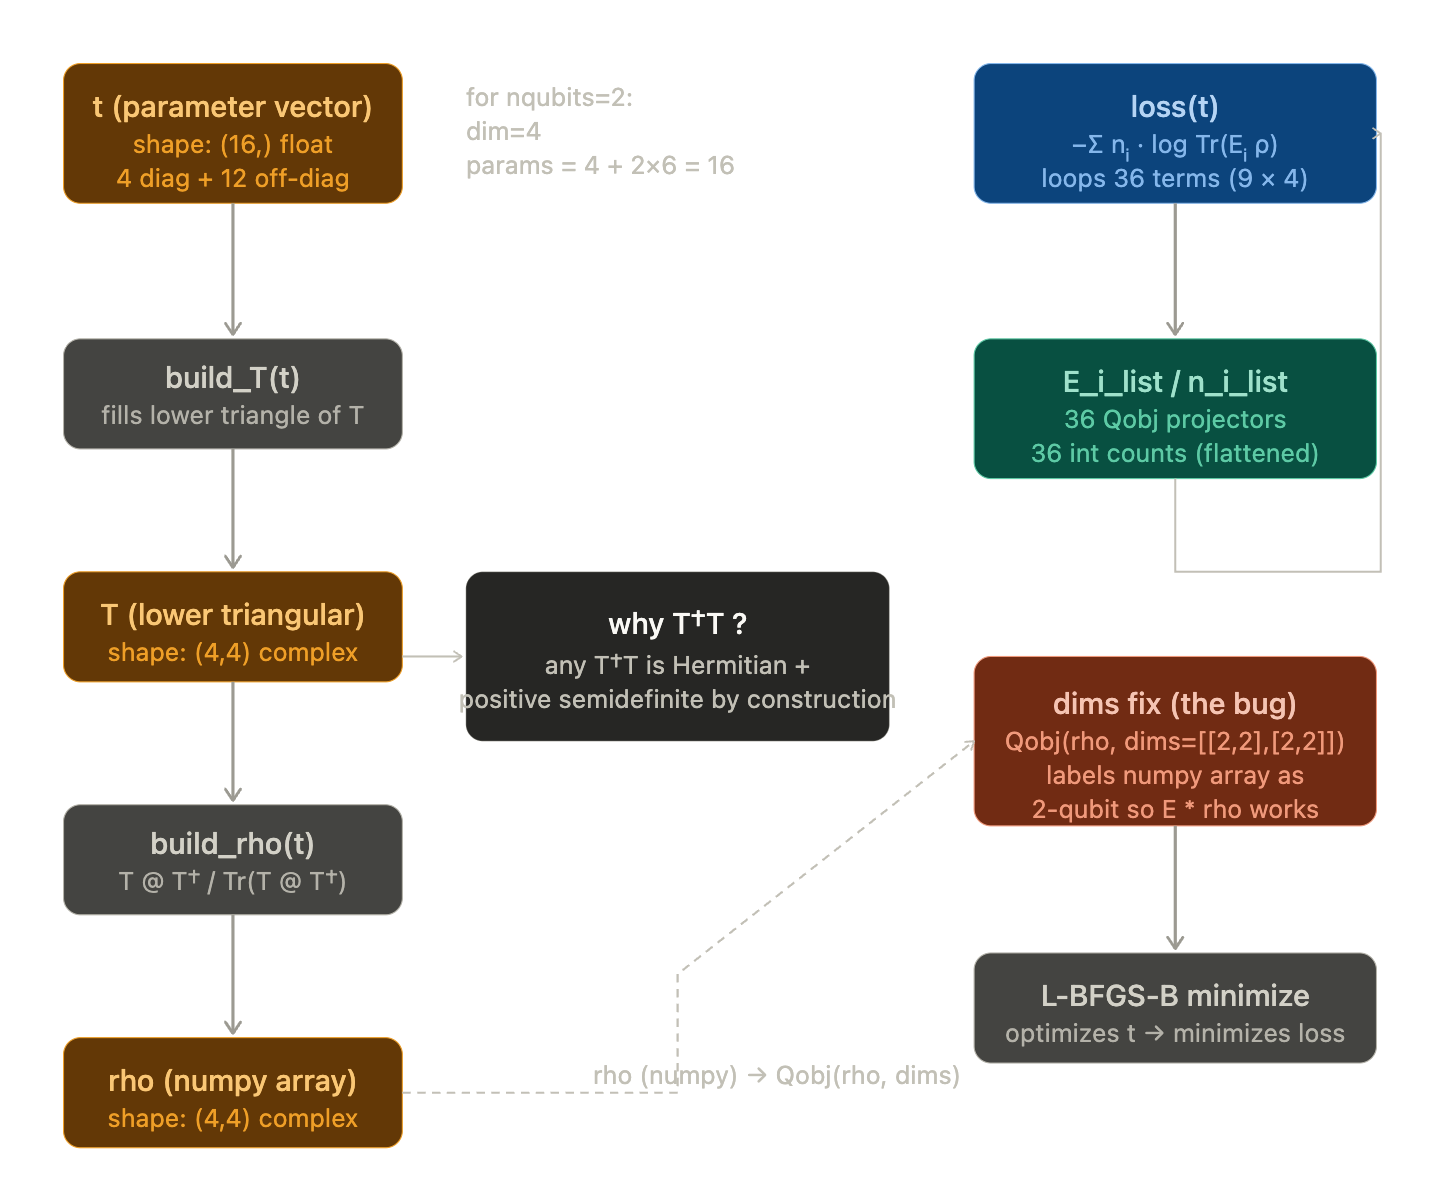


test_MLE()
   ↓
max_likelihood_estimation()
   ├── calc_probs()
   │      ├── build projectors (E_i)
   │      └── compute true probabilities Tr(ρE)
   │
   ├── measure_qubits()
   │      ├── sample outcomes (np.random.choice)
   │      ├── build counts n_i
   │      └── build probabilities p̂_i
   │
   ├── flatten
   │      ├── E_i_list (36 projectors)
   │      └── n_i_list (36 counts)
   │
   ├── optimizer (minimize)
   │      └── repeatedly calls:
   │
   │          loss(t)
   │             ↓
   │          build_rho(t)
   │             ↓
   │          build_T(t)
   │             ↓
   │          compute p_i = Tr(ρE_i)
   │             ↓
   │          compute -Σ n_i log p_i
   │
   └── return final ρ

        DATA (fixed)                        MODEL (changing)
────────────────────────────      ────────────────────────────

true ρ                             t (parameters)
  ↓                                 ↓
calc_probs()                        build_T(t)
  ↓                                 ↓
E_i (projectors)                    T (lower triangular)
  ↓                                 ↓
measure_qubits()                    build_rho(t)
  ↓                                 ↓
n_i (counts)                        ρ = TT† / Tr
                                      ↓
                                   p_i = Tr(ρE_i)

─────────────── COMPARISON ───────────────

        loss = - Σ n_i log p_i

─────────────── OPTIMIZATION ─────────────

        optimizer updates t

Shapes for 2 Qubits

dim = 2^n = 4
settings = 3^n = 9
outcomes = 2^n = 4

tensor_mat:
    9 settings → each has 4 projectors

count_list:
    shape (9, 4)

flatten:
    E_i_list → length 36
    n_i_list → length 36

T:
    shape (4,4)

ρ:
    shape (4,4)

t:
    length 16


            SETTINGS (3^n)
        ┌────────┬────────┬────────┐
        │   XX   │   XY   │   XZ   │
        ├────────┼────────┼────────┤
        │   YX   │   YY   │   YZ   │
        ├────────┼────────┼────────┤
        │   ZX   │   ZY   │   ZZ   │
        └────────┴────────┴────────┘
              (for n = 2 → 9)


OUTCOMES (2^n)
(+1,+1)
(+1,-1)
(-1,+1)
(-1,-1)